# Data Mining Techniques - Assignment 1
Yara Berkelmans - 
Max van Beusekom - 
Younes el Faghloumi - 

In [37]:
# all imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.tsa.ar_model import AutoReg
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    balanced_accuracy_score
)
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Task 1A 

In [9]:
DATA_PATH = "dataset_mood_smartphone.csv"

df = pd.read_csv(DATA_PATH)
df['time'] = pd.to_datetime(df['time'])
print(df.head(10))

   Unnamed: 0       id                time variable  value
0           1  AS14.01 2014-02-26 13:00:00     mood    6.0
1           2  AS14.01 2014-02-26 15:00:00     mood    6.0
2           3  AS14.01 2014-02-26 18:00:00     mood    6.0
3           4  AS14.01 2014-02-26 21:00:00     mood    7.0
4           5  AS14.01 2014-02-27 09:00:00     mood    6.0
5           6  AS14.01 2014-02-27 12:00:00     mood    6.0
6           7  AS14.01 2014-02-27 15:00:00     mood    7.0
7           8  AS14.01 2014-03-21 09:00:00     mood    6.0
8           9  AS14.01 2014-03-21 11:00:00     mood    6.0
9          10  AS14.01 2014-03-21 15:00:00     mood    7.0


In [11]:
print(f"General Information")

print(f"\nNumber of records   : {len(df)}")
print(f"Number of columns   : {df.shape[1]}")
print(f"Number of users: {df['id'].nunique()} ")
print(f"Number of days: {df['time'].dt.date.nunique()} ")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")

print("\nRange per variable:")
print(df.groupby('variable')['value'].agg(['min', 'max']).round(2))


General Information

Number of records   : 376912
Number of columns   : 5
Number of users: 27 
Number of days: 113 

Data types:
Unnamed: 0             int64
id                       str
time          datetime64[us]
variable                 str
value                float64
dtype: object

Missing values per column:
Unnamed: 0      0
id              0
time            0
variable        0
value         202
dtype: int64

Range per variable:
                           min       max
variable                                
activity                  0.00      1.00
appCat.builtin       -82798.87  33960.25
appCat.communication      0.01   9830.78
appCat.entertainment     -0.01  32148.68
appCat.finance            0.13    355.51
appCat.game               1.00   5491.79
appCat.office             0.00  32708.82
appCat.other              0.01   3892.04
appCat.social             0.09  30000.91
appCat.travel             0.08  10452.62
appCat.unknown            0.11   2239.94
appCat.utilities          0

In [12]:
var_counts = df.groupby('variable')['value'].count()
var_mean   = df.groupby('variable')['value'].mean().round(4)
var_stdv   = df.groupby('variable')['value'].std().round(4)
tabel = pd.DataFrame({
    'count': var_counts,
    'mean':  var_mean,
    'std':   var_stdv
})

tabel = tabel.sort_values('count', ascending=False)
print(tabel)

                      count      mean       std
variable                                       
screen                96578   75.3352  253.8225
appCat.builtin        91288   18.5383  415.9892
appCat.communication  74276   43.3438  128.9128
appCat.entertainment  27125   37.5765  262.9605
activity              22965    0.1160    0.1869
appCat.social         19145   72.4019  261.5518
appCat.other           7650   25.8108  112.7814
appCat.office          5642   22.5789  449.6014
mood                   5641    6.9926    1.0328
circumplex.arousal     5597   -0.0986    1.0519
circumplex.valence     5487    0.6878    0.6713
call                   5239    1.0000    0.0000
appCat.travel          2846   45.7308  246.1093
appCat.utilities       2487   18.5376   60.9591
sms                    1798    1.0000    0.0000
appCat.unknown          939   45.5530  119.4004
appCat.finance          939   21.7553   39.2184
appCat.game             813  128.3916  327.1452
appCat.weather          255   20.1487   

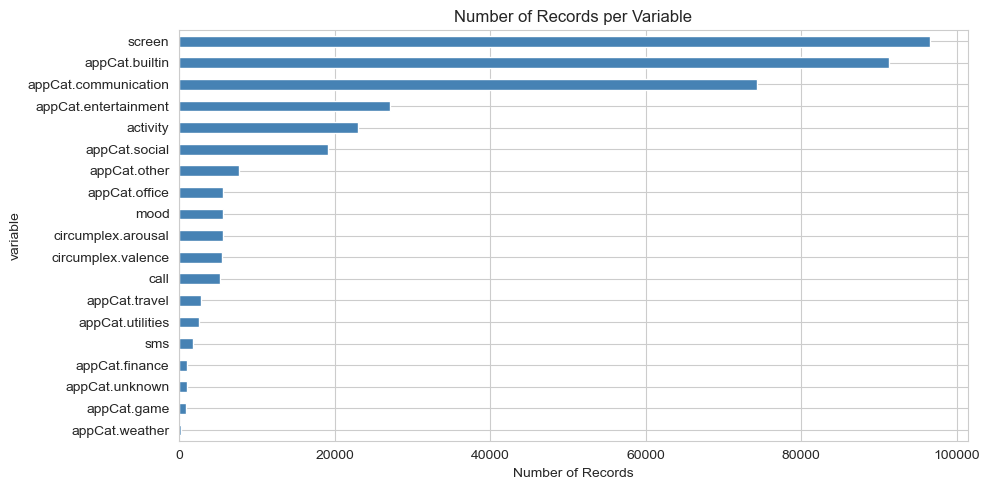

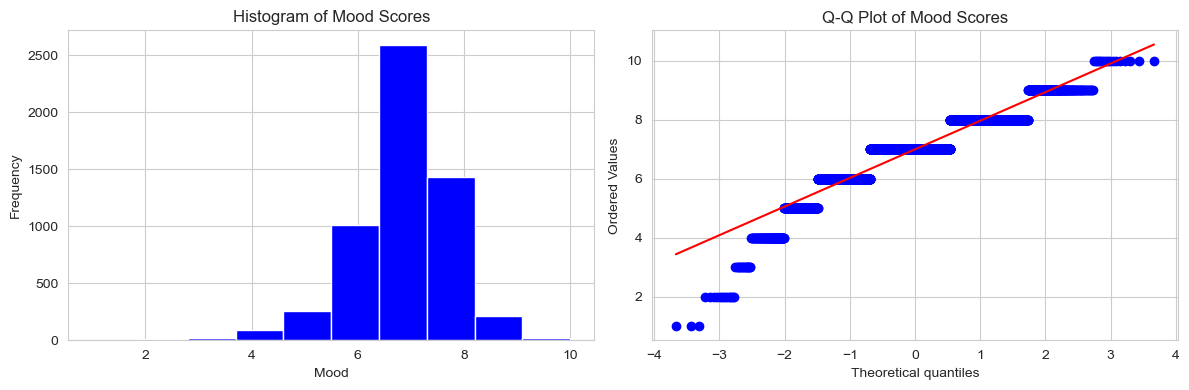

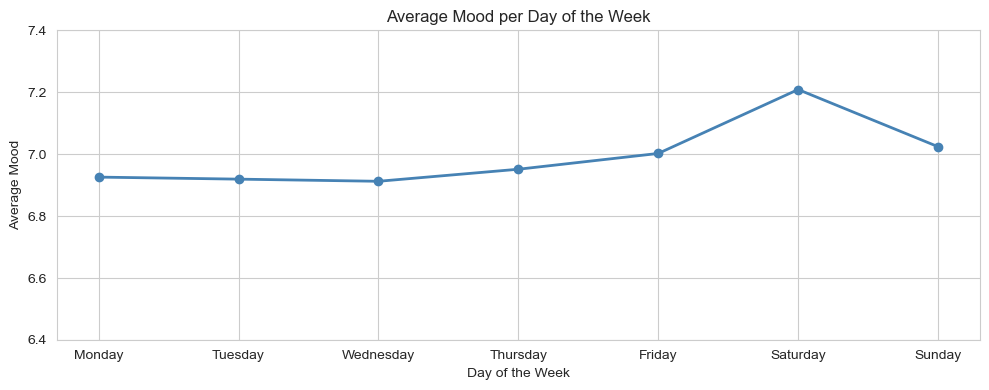

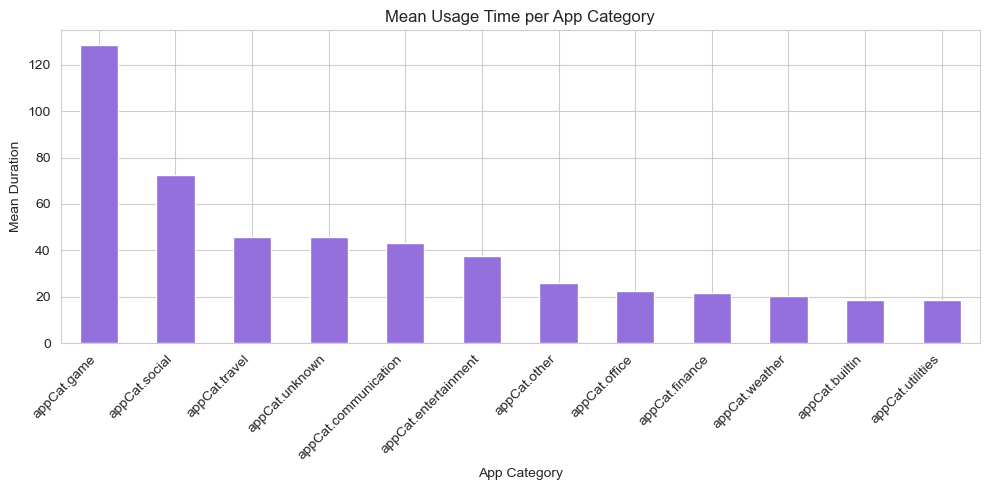

In [14]:
### Plots

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10})


### Plot1: Records per Variable
var_counts = df.groupby('variable')['value'].count().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
var_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel("Number of Records")
ax.set_title("Number of Records per Variable")
plt.tight_layout()
plt.show()

### Plot2: Mood Distribution and QQ plot
mood_vals = df[df['variable'] == 'mood']['value'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mood_vals, bins=10, color='blue', edgecolor='white')
axes[0].set_title("Histogram of Mood Scores")
axes[0].set_xlabel("Mood")
axes[0].set_ylabel("Frequency")

stats.probplot(mood_vals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Mood Scores")

plt.tight_layout()
plt.show()


### Plot3: Avg mood per day
mood_df = df[df['variable'] == 'mood'].copy()
mood_df['weekday'] = mood_df['time'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_by_day = mood_df.groupby('weekday')['value'].mean().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(10, 4))
avg_by_day.plot(ax=ax, marker='o', color='steelblue', linewidth=2)
ax.set_title("Average Mood per Day of the Week")
ax.set_xlabel("Day of the Week")
ax.set_ylabel("Average Mood")
ax.set_ylim(6.4, 7.4)
plt.tight_layout()
plt.show()


### Plot4: App Category Usage
app_vars = [v for v in df['variable'].unique() if v.startswith('appCat.')]
app_means = df[df['variable'].isin(app_vars)].groupby('variable')['value'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
app_means.plot(kind='bar', color='mediumpurple', edgecolor='white', ax=ax)
ax.set_title("Mean Usage Time per App Category")
ax.set_xlabel("App Category")
ax.set_ylabel("Mean Duration")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Plot5: 


# Task 1B

In [15]:
### Remove incorrect parts using ranges time calculated in seconds in a day
VALID_RANGES = {
    'mood':                 (1,     10),
    'circumplex.arousal':   (-2,    2),
    'circumplex.valence':   (-2,    2),
    'activity':             (0,     1),
    'call':                 (0,     1),
    'sms':                  (0,     1),
    'screen':               (0, 86400),
    'appCat.builtin':       (0, 86400),
    'appCat.communication': (0, 86400),
    'appCat.entertainment': (0, 86400),
    'appCat.finance':       (0, 86400),
    'appCat.game':          (0, 86400),
    'appCat.office':        (0, 86400),
    'appCat.other':         (0, 86400),
    'appCat.social':        (0, 86400),
    'appCat.travel':        (0, 86400),
    'appCat.unknown':       (0, 86400),
    'appCat.utilities':     (0, 86400),
    'appCat.weather':       (0, 86400),
}

df_clean = df.copy()

for var, (var_min, var_max) in VALID_RANGES.items():
    x = df_clean['variable'] == var
    bad_value = x & ((df_clean['value'] < var_min) | (df_clean['value'] > var_max))
    n    = bad_value.sum()
    if n > 0:
        print(f"  {var}: removed {n} out-of-range values (range [{var_min}, {var_max}])")
    df_clean.loc[bad_value, 'value'] = np.nan
    
print(f"\n NA before cleaning: {df['value'].isna().sum()}")
print(f" Na after  cleaning: {df_clean['value'].isna().sum()}")

  appCat.builtin: removed 3 out-of-range values (range [0, 86400])
  appCat.entertainment: removed 1 out-of-range values (range [0, 86400])

 NA before cleaning: 202
 Na after  cleaning: 206


In [16]:
### Data aggregation based per day per user
# days removed where mood is unknown 
df_clean['date'] = df_clean['time'].dt.normalize()

sum_vars  = [k for k in VALID_RANGES
             if k.startswith('appCat') or k in ('screen','call','sms')]
mean_vars = ['mood','circumplex.arousal','circumplex.valence','activity']

def aggregate(group):
    var = group.name[2]
    return group['value'].sum() if var in sum_vars else group['value'].mean()

daily = (
    df_clean
    .groupby(['id', 'date', 'variable'])
    .apply(aggregate)
    .reset_index(name='value')
    .pivot_table(index=['id','date'], columns='variable', values='value')
    .reset_index()
)


daily = daily.dropna(subset=['mood']).copy()
daily = daily.sort_values(['id','date']).reset_index(drop=True)



feature_cols = [c for c in daily.columns if c not in ['id','date','mood']]

print(f"\nDaily dataset shape: {daily.shape}")
print(f"\nMissing values per feature:")
print(daily[feature_cols].isnull().sum().sort_values(ascending=False))


Daily dataset shape: (1268, 21)

Missing values per feature:
variable
appCat.weather          1157
appCat.game             1079
appCat.finance          1062
appCat.unknown          1013
appCat.office            998
appCat.travel            850
appCat.utilities         844
sms                      840
call                     528
appCat.entertainment     445
appCat.social            306
appCat.other             165
appCat.communication     121
activity                 118
appCat.builtin           111
screen                   100
circumplex.valence         2
circumplex.arousal         0
dtype: int64


In [17]:
### linear interpolation first method time series. 
# For handling prolonged gaps limit of 7 days is used. in that case median used.

daily_interp = daily.copy()

daily_interp[feature_cols] = (
    daily_interp
    .groupby('id')[feature_cols]
    .transform(lambda x: x.interpolate(limit=7))
)


daily_interp[feature_cols] = (
    daily_interp
    .groupby('id')[feature_cols]
    .transform(lambda x: x.fillna(x.median()))
)


daily_interp[feature_cols] = daily_interp[feature_cols].fillna(daily_interp[feature_cols].median())

print(f"\nNaNs after linear interpolation: "
 f"{daily_interp[feature_cols].isnull().sum().sum()}")


NaNs after linear interpolation: 0


In [18]:
###AR(1) model

def impute_ar(series, lag=1, min_obs=5):
    # save original index — transform passes e.g. 47..87 for user 2
    original_index = series.index
    series = series.copy().reset_index(drop=True)

    #  never recorded 
    if series.notna().sum() == 0:
        result = series.fillna(0)
        result.index = original_index
        return result

    # nothing missing
    if series.isna().sum() == 0:
        series.index = original_index
        return series

    #  too few points to fit AR
    if series.notna().sum() < min_obs:
        result = series.ffill().bfill().fillna(0)
        result.index = original_index
        return result

    #  fit AR(1) on observed values
    try:
        model = AutoReg(series.values, lags=lag, missing='drop').fit()
        preds = model.predict(start=0, end=len(series) - 1)
        series[series.isna()] = preds[series.isna()]
    except Exception:
        result = series.ffill().bfill().fillna(0)
        result.index = original_index
        return result

    series = series.ffill().bfill().fillna(0)
    series.index = original_index
    return series


daily_ar = daily.copy()
for col in feature_cols:
    daily_ar[col] = daily_ar.groupby('id')[col].transform(impute_ar)

print(f"NaNs after AR(1): {daily_ar[feature_cols].isnull().sum().sum()}")

NaNs after AR(1): 0


In [19]:

daily_final = daily_ar.copy()

print(f"\n=== FINAL CLEANED DATASET ===")
print(f"Shape : {daily_final.shape}")
print(f"Users : {daily_final['id'].nunique()}")
print(f"NaNs  : {daily_final[feature_cols].isnull().sum().sum()}")
print(daily_final.head())


=== FINAL CLEANED DATASET ===
Shape : (1268, 21)
Users : 27
NaNs  : 0
variable       id       date  activity  appCat.builtin  appCat.communication  \
0         AS14.01 2014-02-26  0.097919     2157.710462           5921.110004   
1         AS14.01 2014-02-27  0.097919     2157.710462           5921.110004   
2         AS14.01 2014-03-21  0.134050     3139.218000           6280.890000   
3         AS14.01 2014-03-22  0.236880      731.429000           4962.918000   
4         AS14.01 2014-03-23  0.142741     1286.246000           5237.319000   

variable  appCat.entertainment  appCat.finance  appCat.game  appCat.office  \
0                   1185.74713      108.318238    71.833144      42.066662   
1                   1185.74713      108.318238    71.833144      42.066662   
2                   1007.45600       49.544000   154.202530     172.206000   
3                     93.32400       21.076000    71.060902      39.733202   
4                     94.34600       43.403000   125.56392

# Task 1C

In [20]:

WINDOW    = 5
sum_cols  = ['call', 'sms']
sensor_cols = [c for c in daily_final.columns
               if c not in ['id', 'date', 'mood']]

all_instances = []

for user_id, user_data in daily_final.groupby('id'):
    user_data = user_data.sort_values('date').reset_index(drop=True)

    for t in range(WINDOW, len(user_data)):
        history = user_data.iloc[t - WINDOW : t]

        instance = {
            'id'          : user_id,
            'date'        : user_data.loc[t, 'date'],
            'target_mood' : user_data.loc[t, 'mood'],
            'mood_mean_2d': history['mood'].mean(),
            'mood_std_2d' : history['mood'].std(),
            'mood_lag1'   : user_data.loc[t - 1, 'mood'],
            'weekday'     : user_data.loc[t, 'date'].dayofweek,
        }

        
        for col in sensor_cols:
            instance[f'{col}_mean_2d'] = history[col].mean()

        
        for col in sum_cols:
            instance[f'{col}_sum_2d'] = history[col].sum()

        all_instances.append(instance)

df_model = pd.DataFrame(all_instances).reset_index(drop=True)

feat_cols_model = [c for c in df_model.columns
                   if c not in ['id', 'date', 'target_mood']]

print("=== 1C OUTPUT ===")
print(f"Shape          : {df_model.shape}")
print(f"Total instances: {len(df_model)}")
print(f"Feature count  : {len(feat_cols_model)}")

=== 1C OUTPUT ===
Shape          : (1133, 27)
Total instances: 1133
Feature count  : 24


# Task 2A 
### Random Forest Classification 

In [44]:
# helpers 

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# low / medium / high mood
N_CLASSES = 3  

def make_class_bins_from_train(y_train_cont, n_classes=3):
    """
    Compute bin edges from training data to convert continuous values into discrete classes.
    """
    q = np.linspace(0, 1, n_classes + 1)
    edges = np.quantile(y_train_cont, q)
    edges = np.unique(edges)

    if len(edges) < n_classes + 1:
        edges = np.linspace(y_train_cont.min(), y_train_cont.max(), n_classes + 1)

    edges[0] = -np.inf
    edges[-1] = np.inf
    return edges


def apply_bins(y, edges):
    """
    Convert continuous values into discrete class labels based on bin edges. 
    """
    return pd.cut(y, bins=edges, labels=False, include_lowest=True).astype(int)


def print_eval(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("Macro F1        :", round(f1_score(y_true, y_pred, average="macro"), 4))
    print("Accuracy        :", round(accuracy_score(y_true, y_pred), 4))
    print("Balanced Acc    :", round(balanced_accuracy_score(y_true, y_pred), 4))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))


In [45]:
# data prep

rf_data = df_model.copy().sort_values(["id", "date"]).reset_index(drop=True)

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(rf_data, groups=rf_data["id"]))

# create train and test sets 
rf_train = rf_data.iloc[train_idx].copy()
rf_test  = rf_data.iloc[test_idx].copy()

rf_edges = make_class_bins_from_train(rf_train["target_mood"].values, n_classes=N_CLASSES)

# apply bins to create labels
rf_train["target_class"] = apply_bins(rf_train["target_mood"], rf_edges)
rf_test["target_class"]  = apply_bins(rf_test["target_mood"], rf_edges)

# define features and targets 
X_train_rf = rf_train[feat_cols_model]
y_train_rf = rf_train["target_class"]
groups_rf  = rf_train["id"]
X_test_rf = rf_test[feat_cols_model]
y_test_rf = rf_test["target_class"]

# check shapes and bin edges 
print("RF train shape:", X_train_rf.shape)
print("RF test shape :", X_test_rf.shape)
print("Class bin edges:", rf_edges)

RF train shape: (873, 24)
RF test shape : (260, 24)
Class bin edges: [-inf 6.8  7.25  inf]


Fitting 5 folds for each of 72 candidates, totalling 360 fits


Best RF params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 400}
Best CV macro-F1: 0.4408

===== Random Forest - Test =====
Macro F1        : 0.5398
Accuracy        : 0.55
Balanced Acc    : 0.5407

Classification report:
              precision    recall  f1-score   support

           0     0.6277    0.6556    0.6413        90
           1     0.5046    0.5851    0.5419        94
           2     0.5088    0.3816    0.4361        76

    accuracy                         0.5500       260
   macro avg     0.5470    0.5407    0.5398       260
weighted avg     0.5484    0.5500    0.5454       260



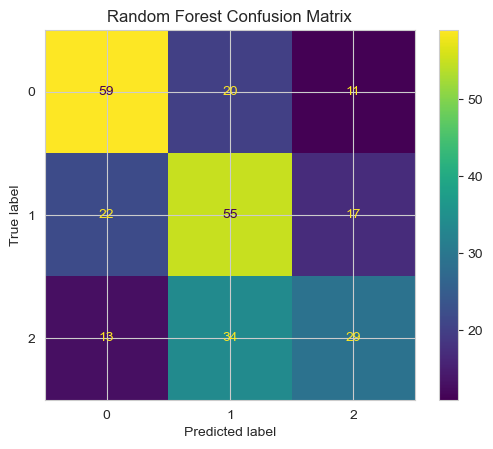

In [46]:
# Random Forest model 
rf = RandomForestClassifier(
    random_state=SEED,
    class_weight="balanced"
)

param_grid_rf = {
    "n_estimators": [200, 400],
    "max_depth": [None, 8, 16],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

cv_rf = GroupKFold(n_splits=min(5, rf_train["id"].nunique()))

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=cv_rf,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_rf, y_train_rf, groups=groups_rf)

best_rf = grid_rf.best_estimator_
rf_pred = best_rf.predict(X_test_rf)

print("Best RF params:", grid_rf.best_params_)
print("Best CV macro-F1:", round(grid_rf.best_score_, 4))

print_eval("Random Forest - Test", y_test_rf, rf_pred)

cm_rf = confusion_matrix(y_test_rf, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

### Recurrent Neural Nerwork (RNN)

In [48]:
#  Keras temporal data prep 

SEQ_LEN = WINDOW 

rnn_feature_cols = [c for c in daily_final.columns if c not in ["id", "date", "mood"]]
rnn_base = daily_final.copy().sort_values(["id", "date"]).reset_index(drop=True)

train_subjects = set(rf_train["id"].unique())
test_subjects = set(rf_test["id"].unique())

rnn_train_base = rnn_base[rnn_base["id"].isin(train_subjects)].copy()
rnn_test_base  = rnn_base[rnn_base["id"].isin(test_subjects)].copy()

# build class bins 
rnn_edges = make_class_bins_from_train(rnn_train_base["mood"].values, n_classes=N_CLASSES)

# scaling on train
scaler_rnn = StandardScaler()
rnn_train_base[rnn_feature_cols] = scaler_rnn.fit_transform(rnn_train_base[rnn_feature_cols])
rnn_test_base[rnn_feature_cols]  = scaler_rnn.transform(rnn_test_base[rnn_feature_cols])

def build_sequences(df_daily, feature_cols, seq_len, class_edges):
    """
    Convert daily time-series data into fixed-length sequences for RNN training
    """
    X_seq, y_seq, ids_seq, dates_seq = [], [], [], []

    for pid, g in df_daily.groupby("id"):
        g = g.sort_values("date").reset_index(drop=True)

        for t in range(seq_len, len(g)):
            X_seq.append(g.loc[t-seq_len:t-1, feature_cols].values.astype(np.float32))
            y_seq.append(int(apply_bins(pd.Series([g.loc[t, "mood"]]), class_edges).iloc[0]))
            ids_seq.append(pid)
            dates_seq.append(g.loc[t, "date"])

    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_seq, dtype=np.int32),
        np.array(ids_seq),
        np.array(dates_seq)
    )

X_train_seq, y_train_seq, ids_train_seq, dates_train_seq = build_sequences(
    rnn_train_base, rnn_feature_cols, SEQ_LEN, rnn_edges
)
X_test_seq, y_test_seq, ids_test_seq, dates_test_seq = build_sequences(
    rnn_test_base, rnn_feature_cols, SEQ_LEN, rnn_edges
)

print("X_train_seq:", X_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)
print("RNN class edges:", rnn_edges)
print("Train class counts:", pd.Series(y_train_seq).value_counts().sort_index().to_dict())
print("Test class counts :", pd.Series(y_test_seq).value_counts().sort_index().to_dict())

X_train_seq: (873, 5, 18)
X_test_seq : (260, 5, 18)
RNN class edges: [      -inf 6.8        7.27777778        inf]
Train class counts: {0: 343, 1: 246, 2: 284}
Test class counts : {0: 90, 1: 94, 2: 76}


In [49]:
# RNN model

classes = np.arange(N_CLASSES)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_seq
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

model = Sequential([
    SimpleRNN(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(N_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Class weights: {0: np.float64(0.8483965014577259), 1: np.float64(1.1829268292682926), 2: np.float64(1.0246478873239437)}


/opt/miniconda3/envs/minai/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         5,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,491 (29.26 KB)

 Trainable params: 7,491 (29.26 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# train RNN model 
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3438 - loss: 1.1571 - val_accuracy: 0.3943 - val_loss: 1.1552
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4456 - loss: 1.0469 - val_accuracy: 0.3943 - val_loss: 1.1444
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4828 - loss: 0.9894 - val_accuracy: 0.3943 - val_loss: 1.1363
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5372 - loss: 0.9651 - val_accuracy: 0.4114 - val_loss: 1.1343
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5745 - loss: 0.9240 - val_accuracy: 0.3714 - val_loss: 1.1566
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5774 - loss: 0.9027 - val_accuracy: 0.3829 - val_loss: 1.1668
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6074 - loss: 0.8814 - val_accuracy: 0.3771 - val_loss: 1.1857
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6189 - loss: 0.8554 - val_accuracy: 0.3657 - val_loss


===== Keras RNN - Test =====
Macro F1        : 0.4374
Accuracy        : 0.4346
Balanced Acc    : 0.4398

Classification report:
              precision    recall  f1-score   support

           0     0.3704    0.4444    0.4040        90
           1     0.6415    0.3617    0.4626        94
           2     0.3939    0.5132    0.4457        76

    accuracy                         0.4346       260
   macro avg     0.4686    0.4398    0.4374       260
weighted avg     0.4753    0.4346    0.4374       260



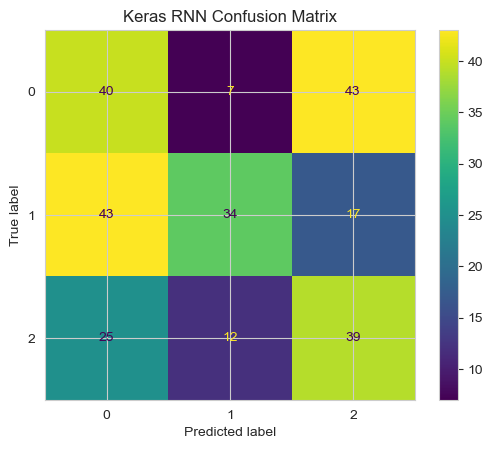

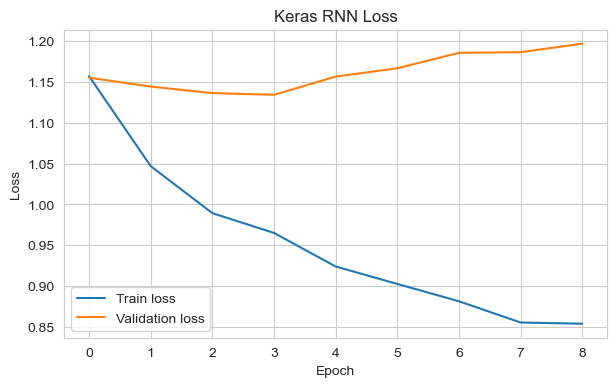

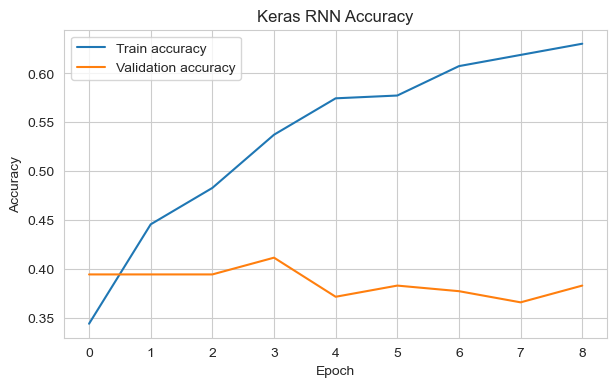

In [51]:
# evaluate 
y_prob_rnn = model.predict(X_test_seq, verbose=0)
y_pred_rnn = np.argmax(y_prob_rnn, axis=1)

print_eval("Keras RNN - Test", y_test_seq, y_pred_rnn)

cm_rnn = confusion_matrix(y_test_seq, y_pred_rnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rnn)
disp.plot()
plt.title("Keras RNN Confusion Matrix")
plt.show()

# training curves 
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.legend()
plt.title("Keras RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.legend()
plt.title("Keras RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


===== Baseline (Most Frequent) =====
Macro F1        : 0.1714
Accuracy        : 0.3462
Balanced Acc    : 0.3333

Classification report:
              precision    recall  f1-score   support

           0     0.3462    1.0000    0.5143        90
           1     0.0000    0.0000    0.0000        94
           2     0.0000    0.0000    0.0000        76

    accuracy                         0.3462       260
   macro avg     0.1154    0.3333    0.1714       260
weighted avg     0.1198    0.3462    0.1780       260



/opt/miniconda3/envs/minai/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/minai/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/minai/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

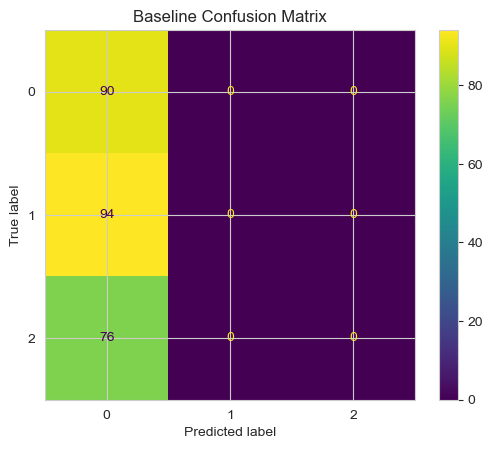

In [53]:
# baseline model (for comparison)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_rf, y_train_rf)

dummy_pred = dummy.predict(X_test_rf)

print_eval("Baseline (Most Frequent)", y_test_rf, dummy_pred)

cm_dummy = confusion_matrix(y_test_rf, dummy_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dummy)
disp.plot()
plt.title("Baseline Confusion Matrix")
plt.show()

In [54]:
# compare all approaches
dummy_macro_f1 = f1_score(y_test_rf, dummy_pred, average="macro")
dummy_acc = accuracy_score(y_test_rf, dummy_pred)
dummy_bal_acc = balanced_accuracy_score(y_test_rf, dummy_pred)

rf_macro_f1 = f1_score(y_test_rf, rf_pred, average="macro")
rf_acc = accuracy_score(y_test_rf, rf_pred)
rf_bal_acc = balanced_accuracy_score(y_test_rf, rf_pred)

rnn_macro_f1 = f1_score(y_test_seq, y_pred_rnn, average="macro")
rnn_acc = accuracy_score(y_test_seq, y_pred_rnn)
rnn_bal_acc = balanced_accuracy_score(y_test_seq, y_pred_rnn)

comparison = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "Keras RNN"],
    "Macro F1": [dummy_macro_f1, rf_macro_f1, rnn_macro_f1],
    "Accuracy": [dummy_acc, rf_acc, rnn_acc],
    "Balanced Accuracy": [dummy_bal_acc, rf_bal_acc, rnn_bal_acc]
}).sort_values("Macro F1", ascending=False)

comparison

,Model,Macro F1,Accuracy,Balanced Accuracy
1,Random Forest,0.539755,0.550000,0.540747
2,Keras RNN,0.437447,0.434615,0.439768
0,Baseline,0.171429,0.346154,0.333333
